In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('kidney_disease.csv')

In [3]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [4]:
df.tail()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd
399,399,58.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,53,6800,6.1,no,no,no,good,no,no,notckd


In [5]:
print("Dataset shape:", df.shape)

Dataset shape: (400, 26)


In [6]:
print("\nMissing values per column:")
df.isnull().sum()


Missing values per column:


id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

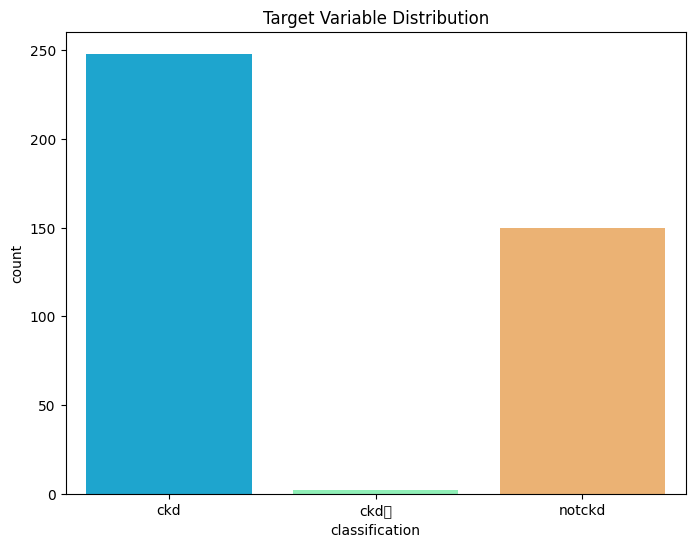

In [7]:
# Explore target variable distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='classification', data=df,palette='rainbow')
plt.title('Target Variable Distribution')
plt.show()

In [8]:
df['classification'].value_counts()

classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64

In [9]:
# Rename columns for consistency
df.columns = df.columns.str.strip()

# Clean the target variable
df['classification'] = df['classification'].replace(['ckd\t', 'ckd', 'notckd'], ['ckd', 'ckd', 'notckd'])

In [10]:
df['classification'].value_counts()

classification
ckd       250
notckd    150
Name: count, dtype: int64

In [11]:
# Replace "?" with NaN
df = df.replace("?", np.nan)

In [12]:
# Convert numeric columns to proper datatype
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="ignore")
print("\nMissing values per column:\n")
df.isnull().sum()


Missing values per column:



id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [13]:
# 2. Handling Missing Values
# Fill numeric NaN with median, categorical with mode
for col in df.columns:
    if df[col].dtype in ['float64','int64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

In [14]:
print("\nMissing values after filling:\n")
df.isnull().sum()


Missing values after filling:



id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

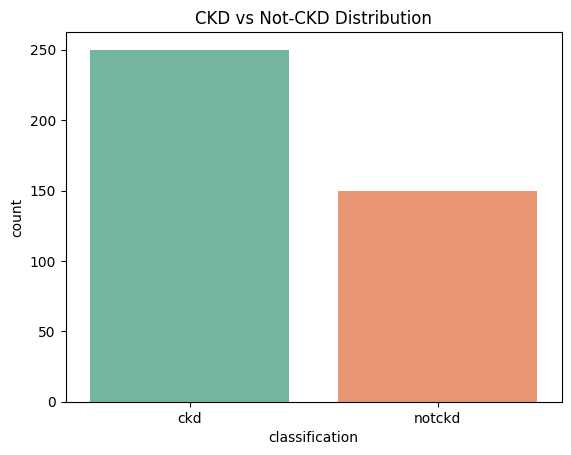

In [15]:
# 3. Target Variable Distribution
sns.countplot(x='classification', data=df, palette="Set2")
plt.title("CKD vs Not-CKD Distribution")
plt.show()

In [16]:
# Summary statistics
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].describe().T 

,count,mean,std,min,25%,50%,75%,max
id,400.0,199.500000,115.614301,0.000,99.750,199.50,299.250,399.000
age,400.0,51.562500,16.982996,2.000,42.000,55.00,64.000,90.000
bp,400.0,76.575000,13.489785,50.000,70.000,80.00,80.000,180.000
sg,400.0,1.017712,0.005434,1.005,1.015,1.02,1.020,1.025
al,400.0,0.900000,1.313130,0.000,0.000,0.00,2.000,5.000
su,400.0,0.395000,1.040038,0.000,0.000,0.00,0.000,5.000
bgr,400.0,145.062500,75.260774,22.000,101.000,121.00,150.000,490.000
bu,400.0,56.693000,49.395258,1.500,27.000,42.00,61.750,391.000
sc,400.0,2.997125,5.628886,0.400,0.900,1.30,2.725,76.000
sod,400.0,137.631250,9.206332,4.500,135.000,138.00,141.000,163.000


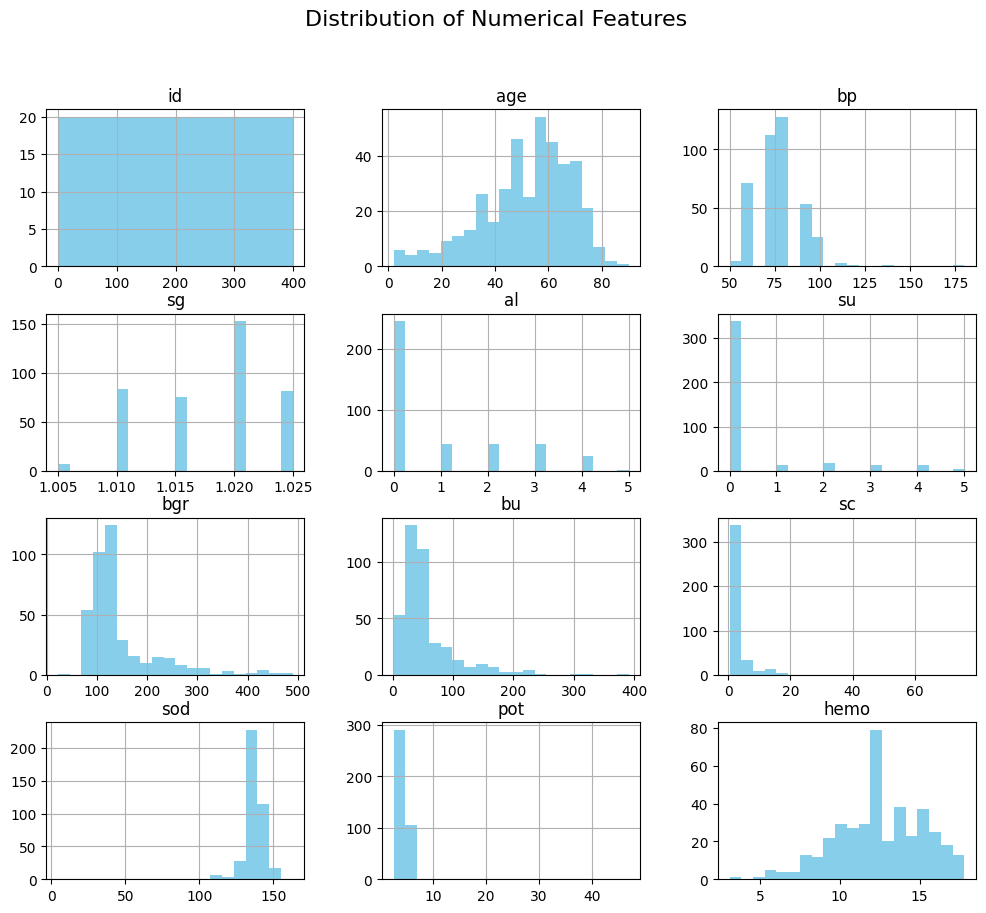

In [17]:
# Histograms for numerical features
df[num_cols].hist(figsize=(12, 10), bins=20, color='skyblue')
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.grid(False)
plt.show()

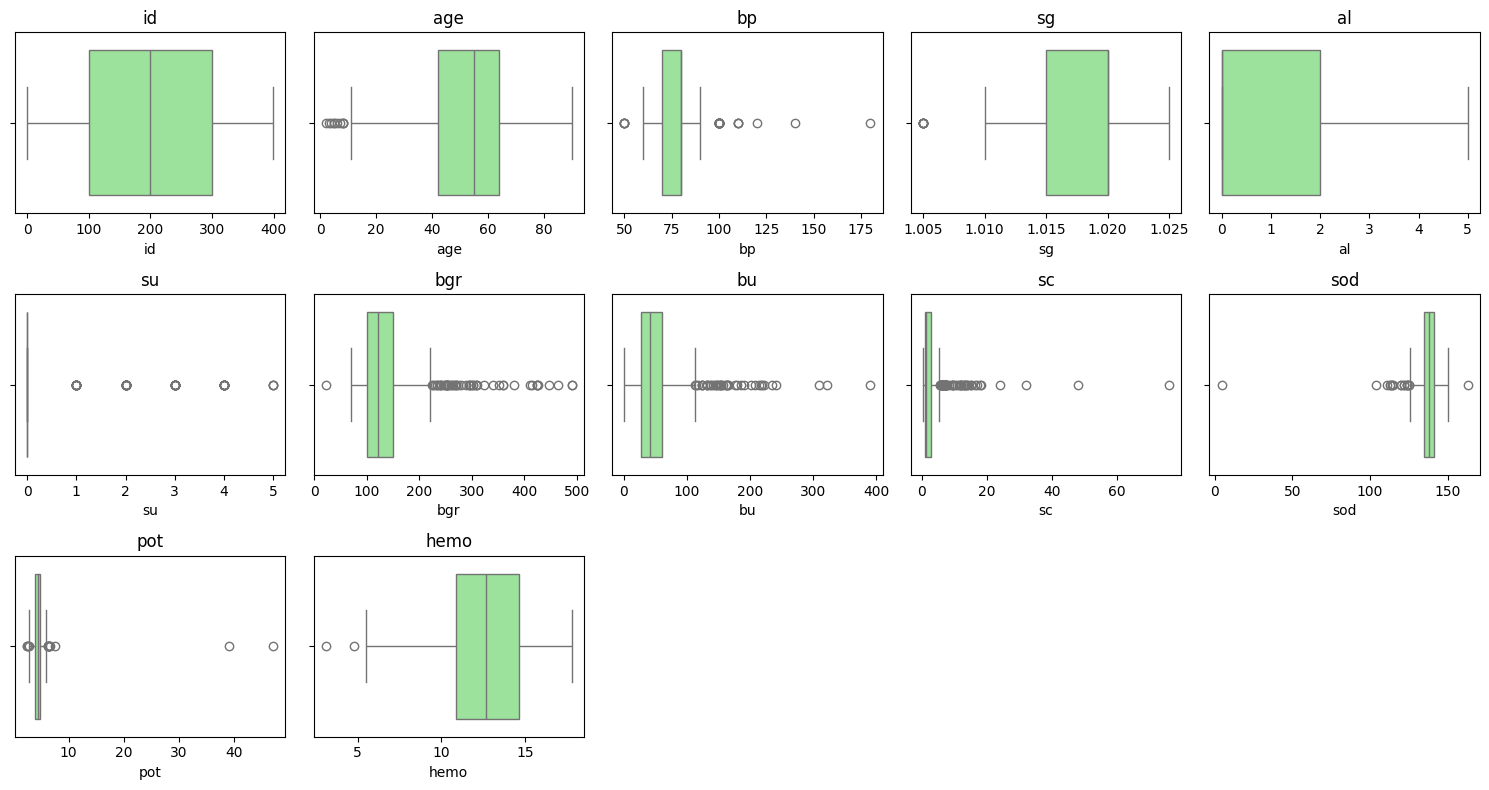

In [18]:
# Boxplots for outliers
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 5, i)
    sns.boxplot(x=df[col], color="lightgreen")
    plt.title(col)
plt.tight_layout()
plt.show()

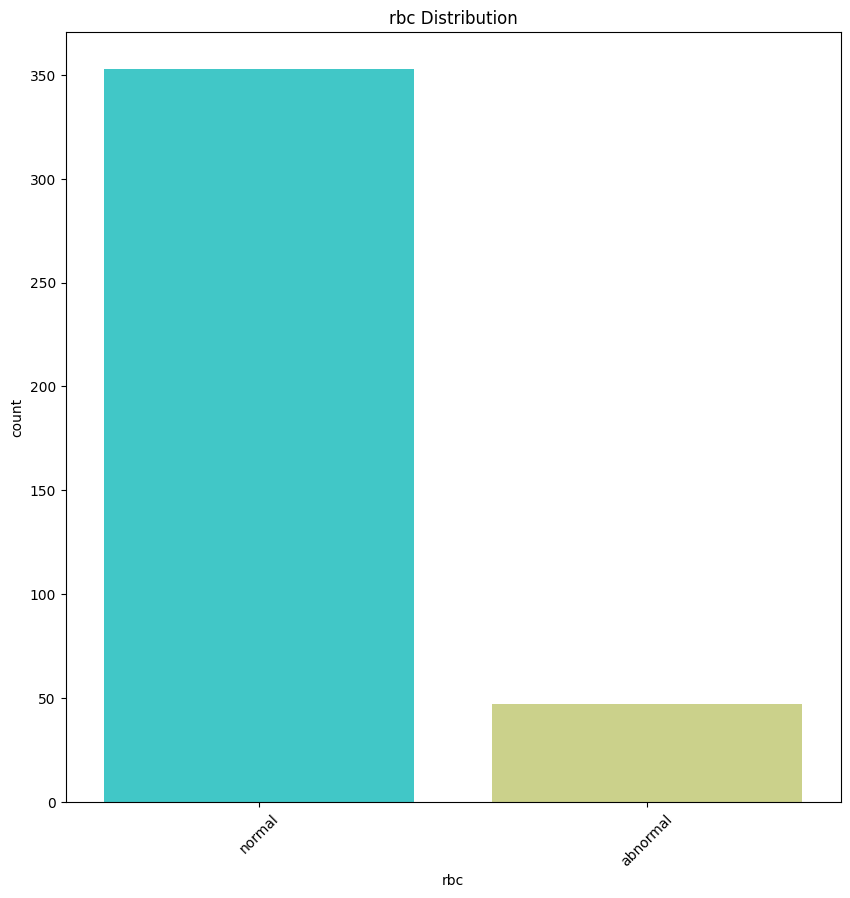

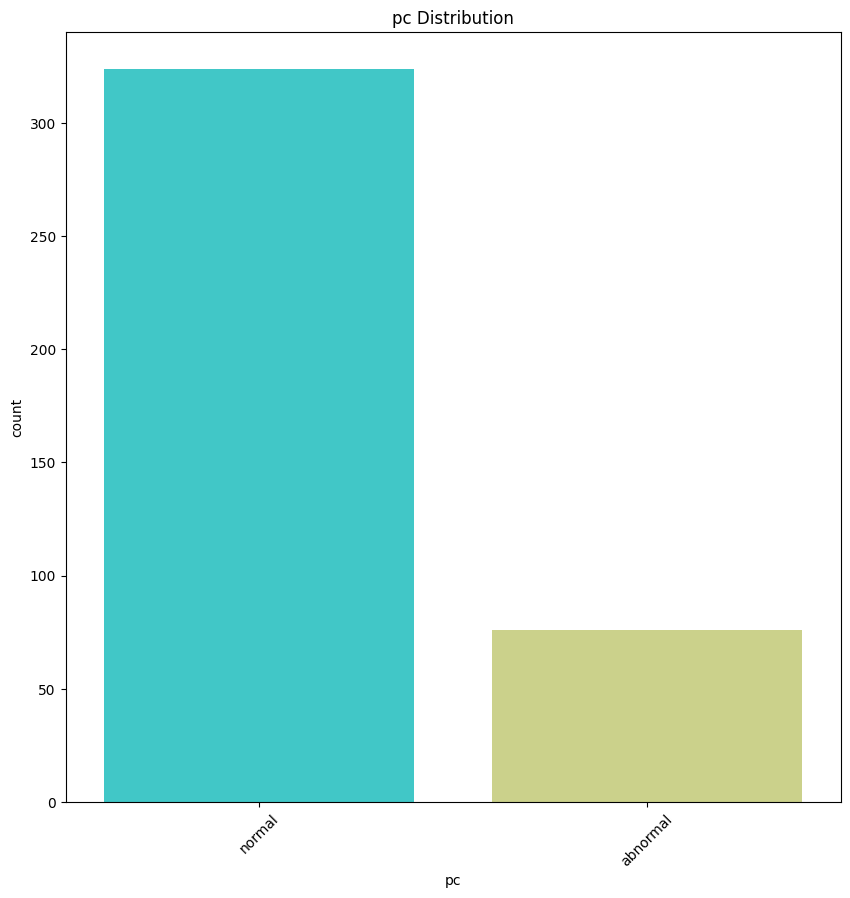

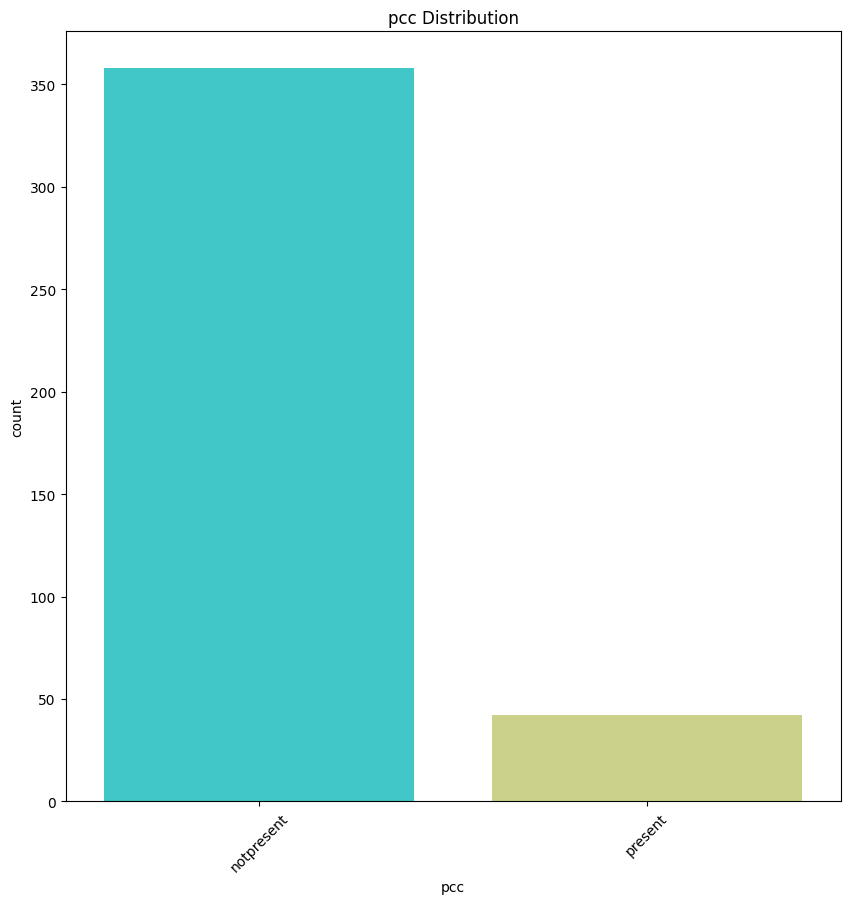

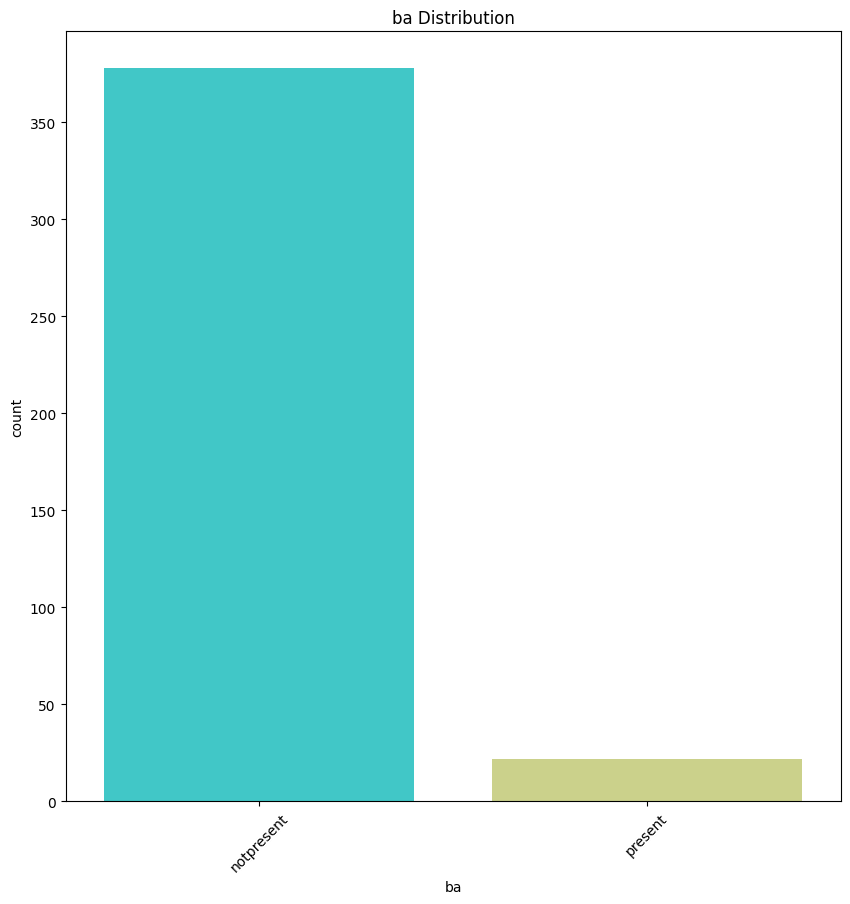

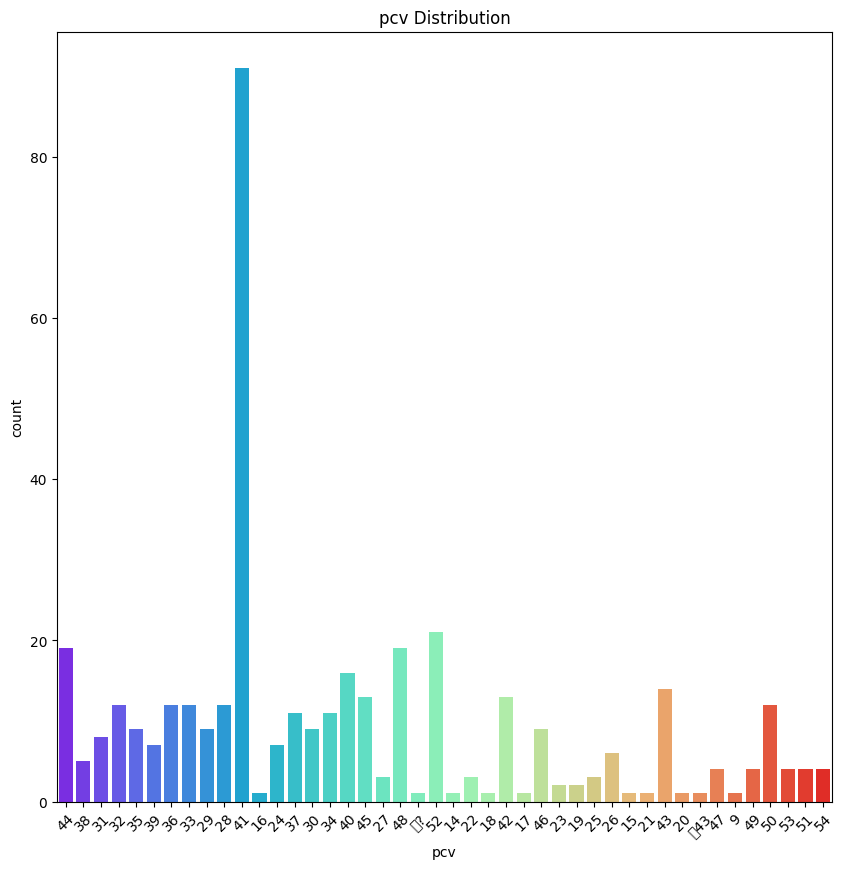

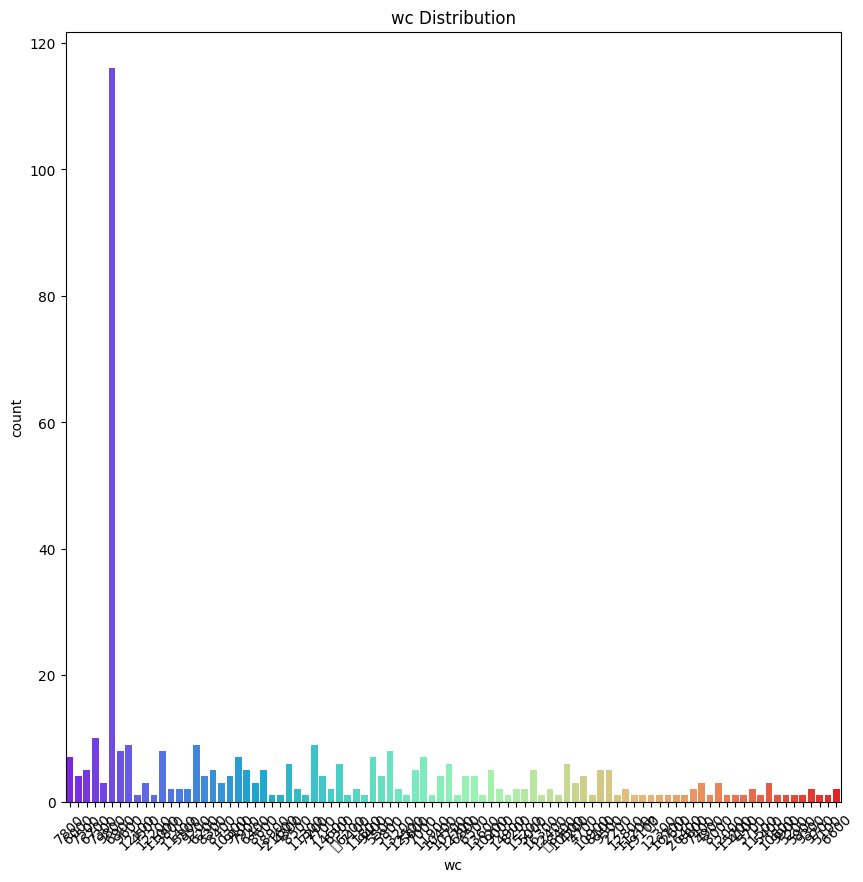

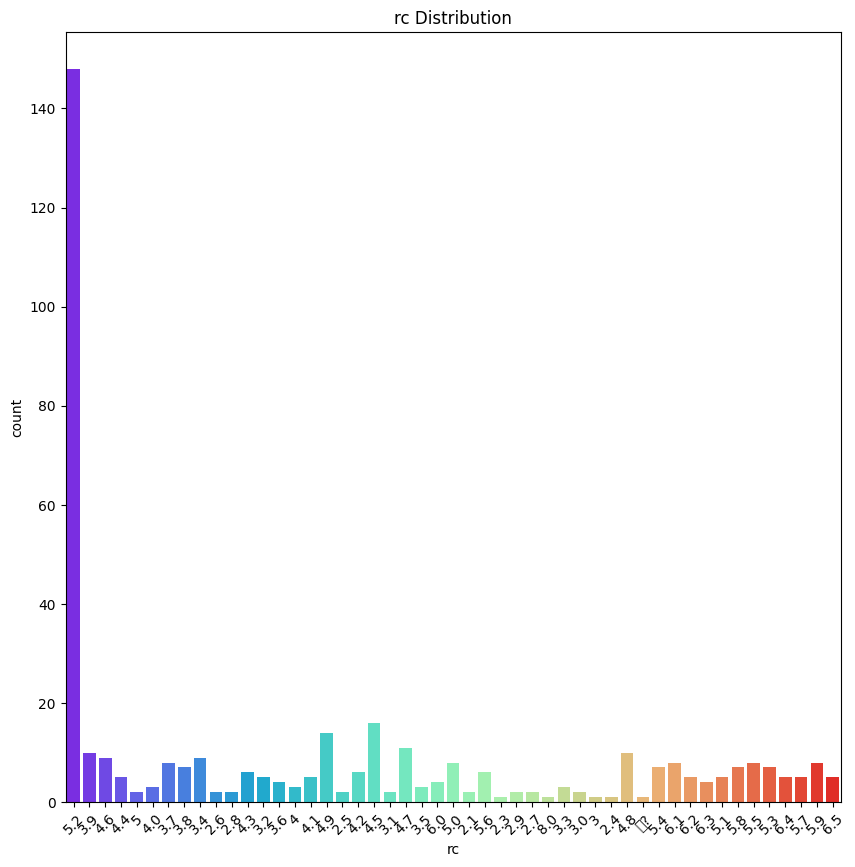

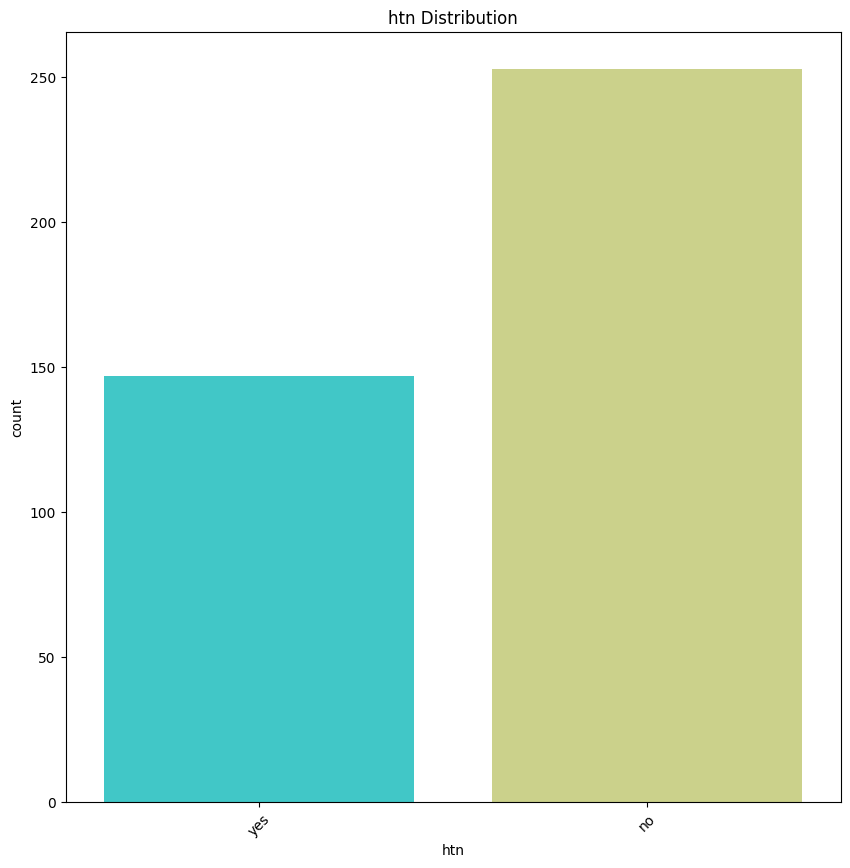

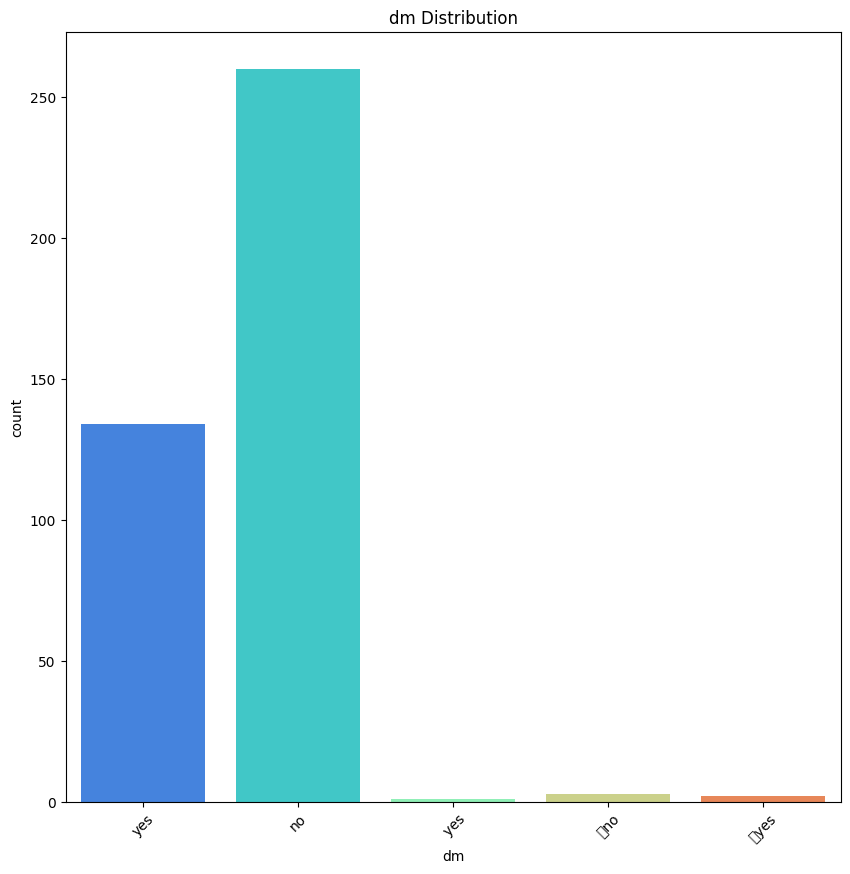

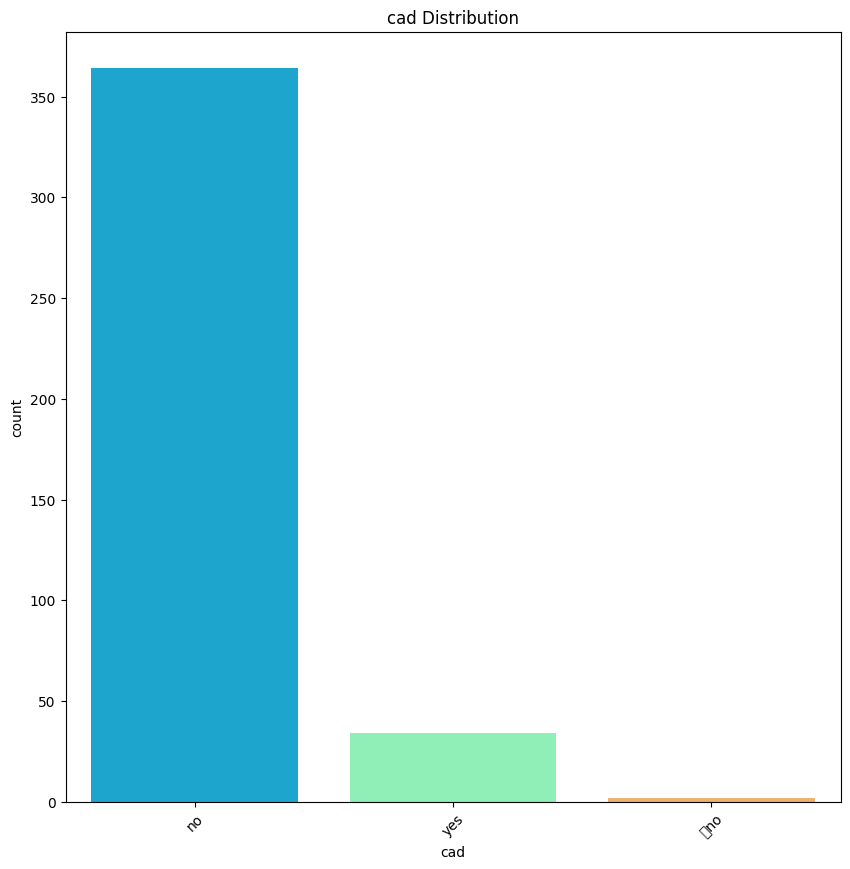

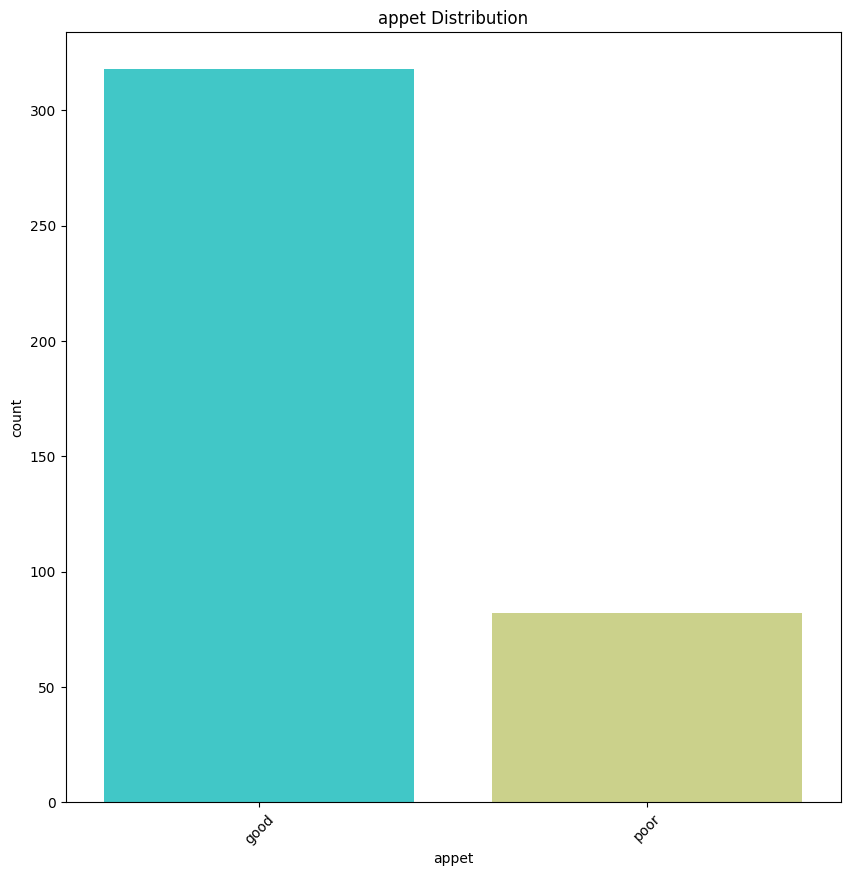

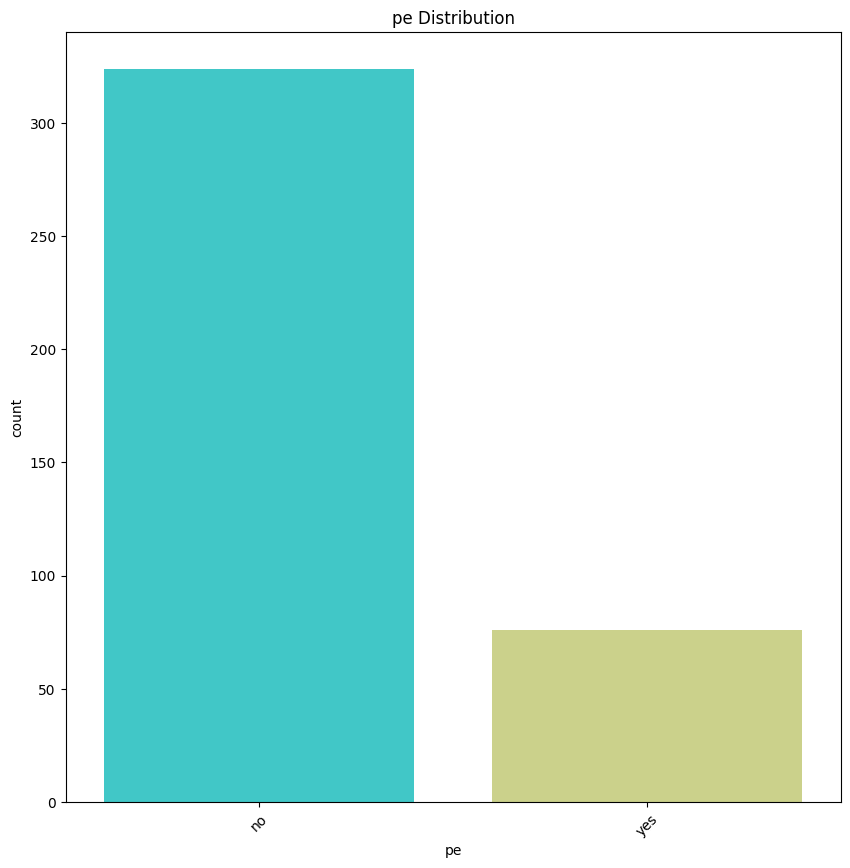

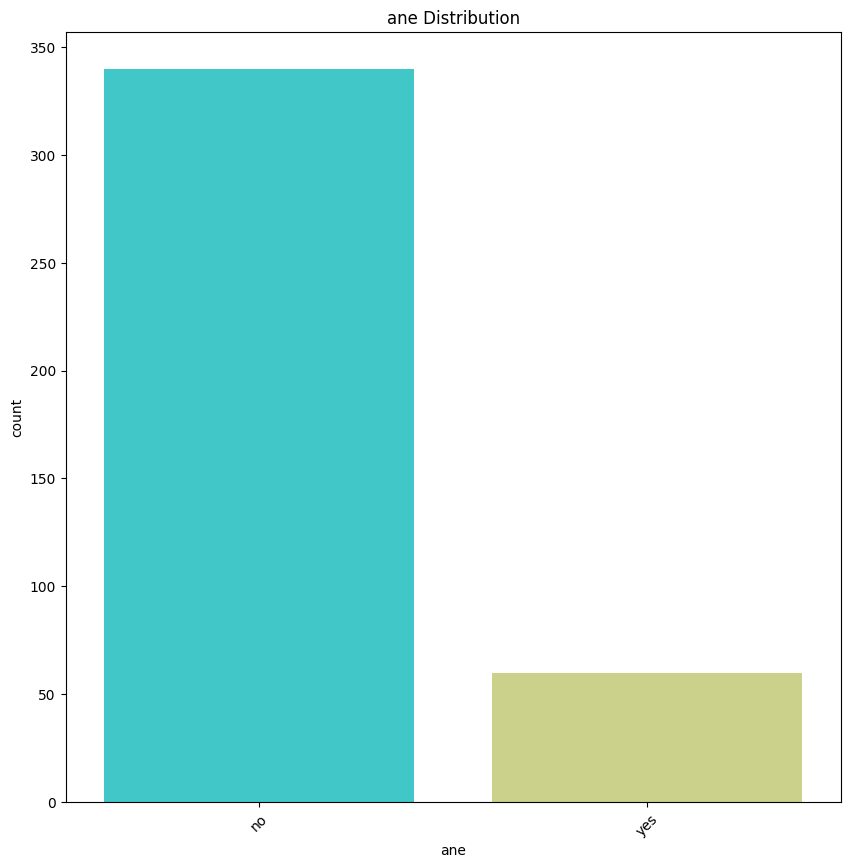

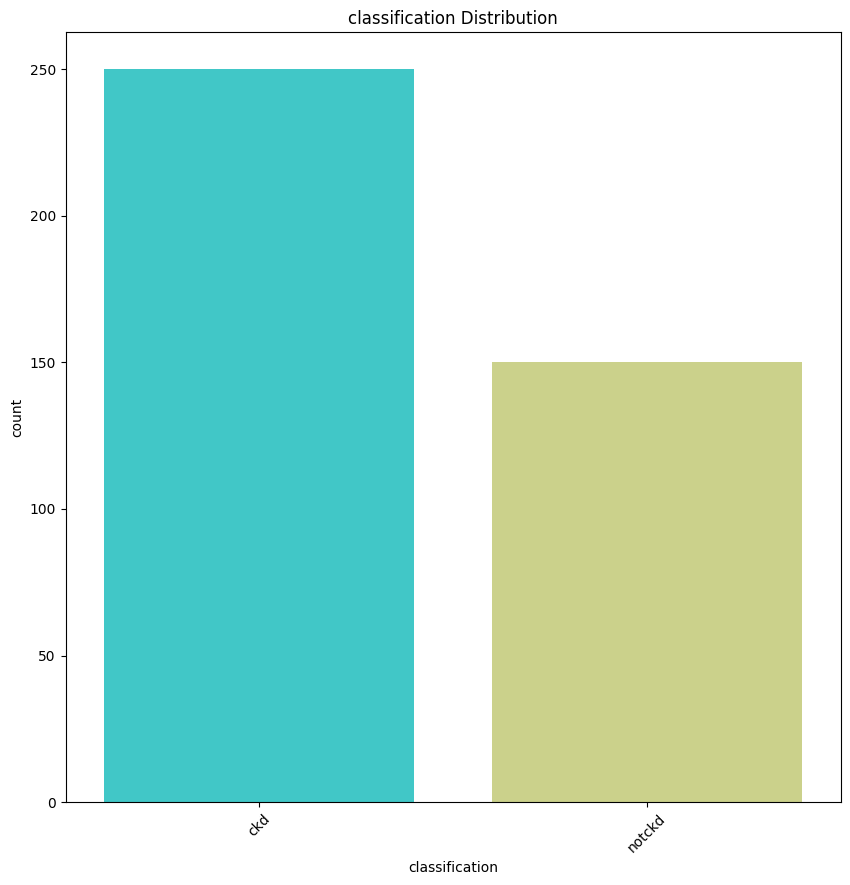

In [19]:
# 4. Categorical Features Analysis
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(10,10))
    sns.countplot(x=col, data=df, palette="rainbow")
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()

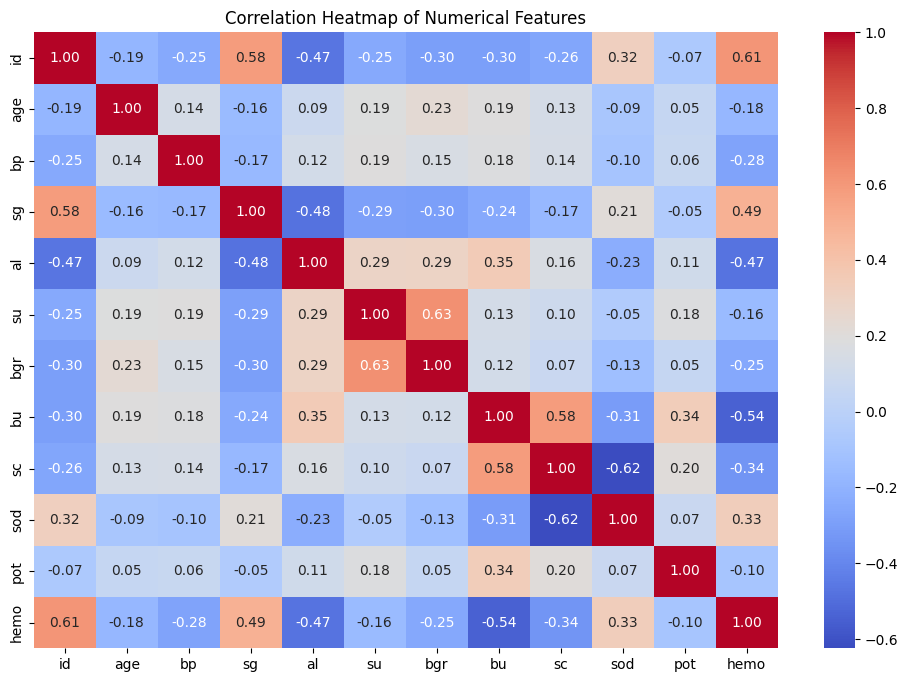

In [20]:
# 5. Correlation Heatmap
plt.figure(figsize=(12,8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

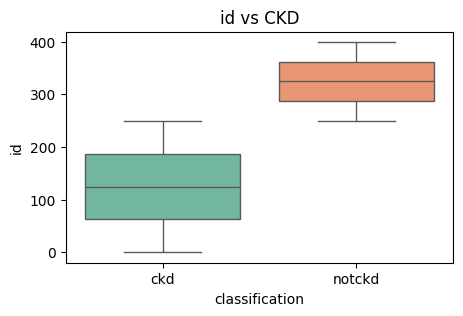

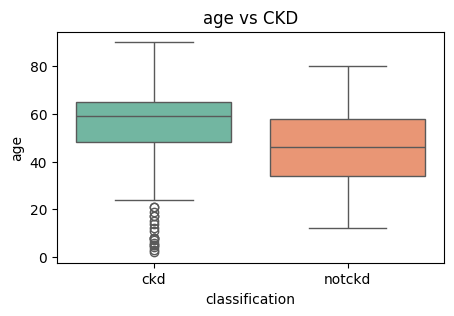

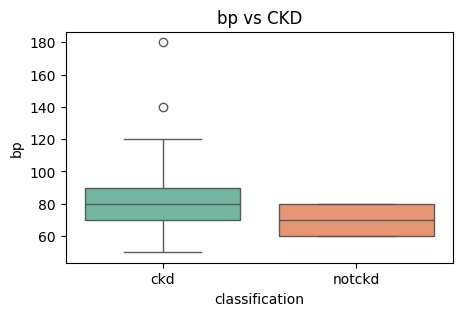

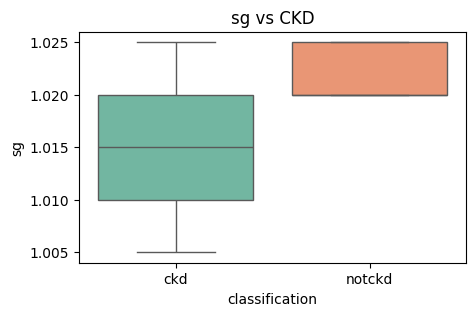

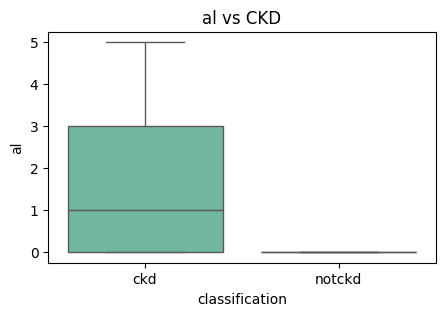

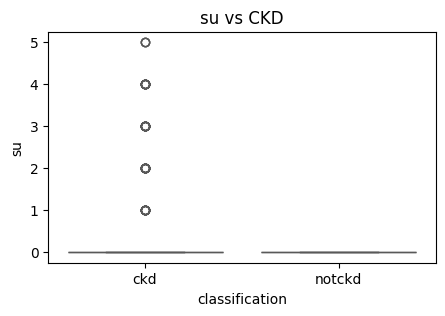

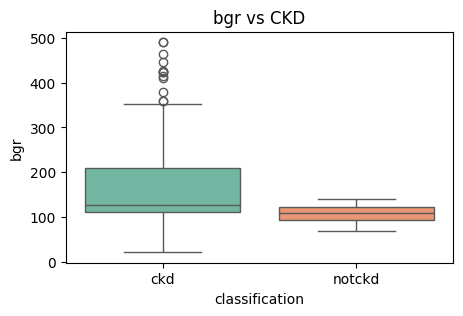

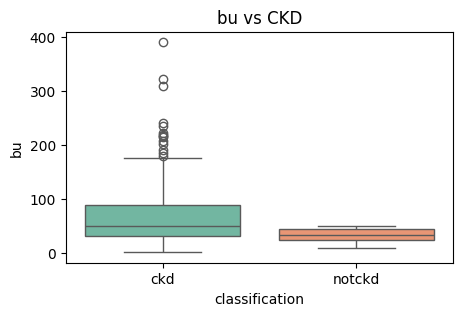

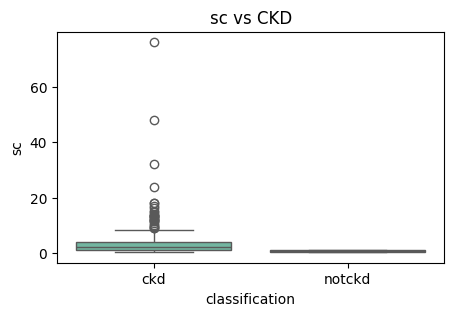

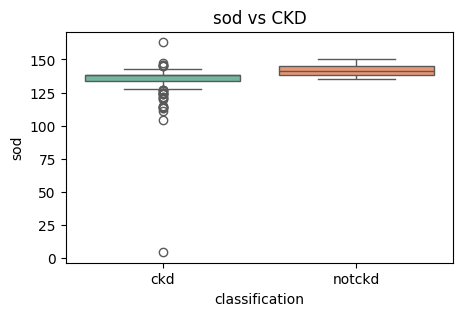

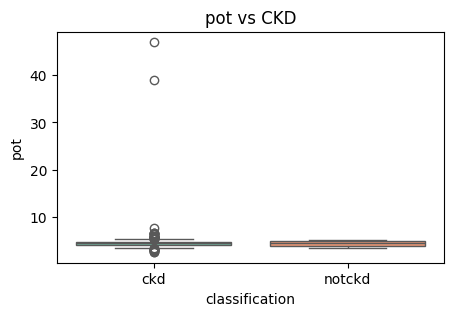

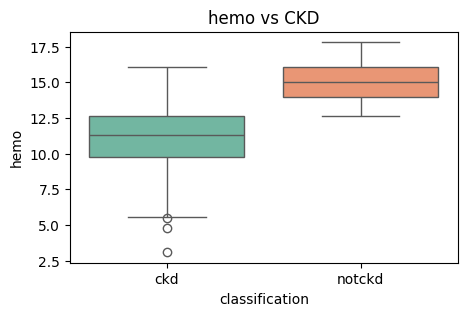

In [21]:
# 6. Feature vs Target Analysis
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x="classification", y=col, data=df, palette="Set2")
    plt.title(f"{col} vs CKD")
    plt.show()

In [22]:
# Encode categorical features
le = LabelEncoder()
df['classification'] = le.fit_transform(df['classification'])

In [24]:
# Encode other categorical features
categorical_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [25]:
# Feature Engineering
# Create new features based on domain knowledge
df['bun_to_creatinine'] = df['bu'] / df['sc']  # Blood Urea Nitrogen to Creatinine Ratio
df['sodium_potassium'] = df['sod'] / df['pot']  # Sodium to Potassium Ratio

In [26]:
# Feature selection - drop redundant features
df = df.drop(['id', 'rc', 'pcv', 'wc'], axis=1)

In [27]:
# Split the data
X = df.drop('classification', axis=1)
y = df['classification']

In [28]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [30]:
# Check new class distribution
print("\nResampled class distribution:")
print(pd.Series(y_train_res).value_counts())


Resampled class distribution:
classification
1    200
0    200
Name: count, dtype: int64


In [31]:
# Build and compare multiple models
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM': SVC(probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Create a pipeline for preprocessing and modeling
results = {}
for name, model in models.items():
    # Create pipeline with scaling and model
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    pipeline.fit(X_train_res, y_train_res)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results[name] = {
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1_score': report['weighted avg']['f1-score']
    }

In [32]:
# Display model comparison
results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(results_df.sort_values('roc_auc', ascending=False))


Model Comparison:
                     accuracy   roc_auc  precision  recall  f1_score
Random Forest          0.9875  1.000000   0.987745  0.9875  0.987456
XGBoost                0.9875  1.000000   0.987745  0.9875  0.987456
SVM                    1.0000  1.000000   1.000000  1.0000  1.000000
Gradient Boosting      0.9875  1.000000   0.987745  0.9875  0.987456
KNN                    0.9625  0.999667   0.965909  0.9625  0.962813
Logistic Regression    0.9875  0.998000   0.987903  0.9875  0.987539


In [33]:
# Hyperparameter tuning for the best model
# Based on results, XGBoost and Random Forest typically perform well
best_model_name = results_df['roc_auc'].idxmax()
print(f"\nBest model for tuning: {best_model_name}")


Best model for tuning: Random Forest


In [34]:
# Define parameter grid for XGBoost
if best_model_name == 'XGBoost':
    param_grid = {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [3, 5, 7],
        'model__subsample': [0.7, 0.9],
        'model__colsample_bytree': [0.7, 0.9]
    }
# Define parameter grid for Random Forest
elif best_model_name == 'Random Forest':
    param_grid = {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2']
    }
else:
    # Default to XGBoost parameters
    best_model_name = 'XGBoost'
    param_grid = {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [3, 5, 7],
        'model__subsample': [0.7, 0.9],
        'model__colsample_bytree': [0.7, 0.9]
    }

In [35]:
# Create pipeline with best model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', models[best_model_name])
])

In [36]:
# Use GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [37]:
grid_search.fit(X_train_res, y_train_res)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [50]:
# Get best model
best_model = grid_search.best_estimator_
print(best_model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier(random_state=42))])


In [46]:
# Evaluate the final model
# Make predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [47]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

In [48]:
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


Best parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Accuracy: 0.9875
ROC AUC: 1.0000

Confusion Matrix:
[[50  0]
 [ 1 29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           1       1.00      0.97      0.98        30

    accuracy                           0.99        80
   macro avg       0.99      0.98      0.99        80
weighted avg       0.99      0.99      0.99        80



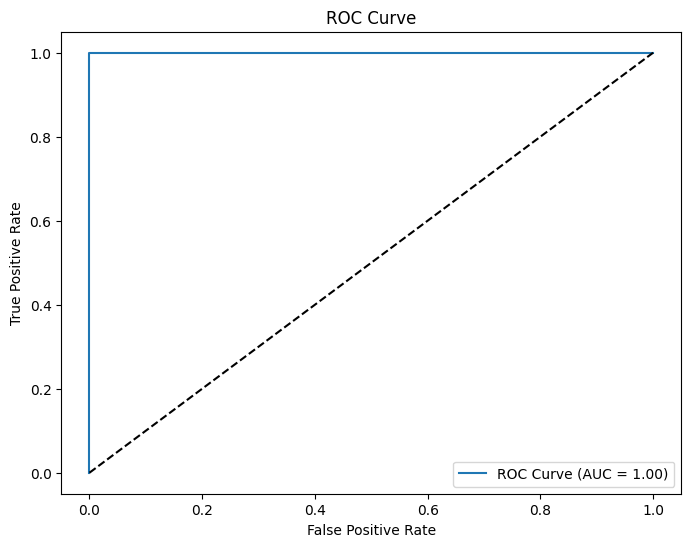

In [42]:
# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

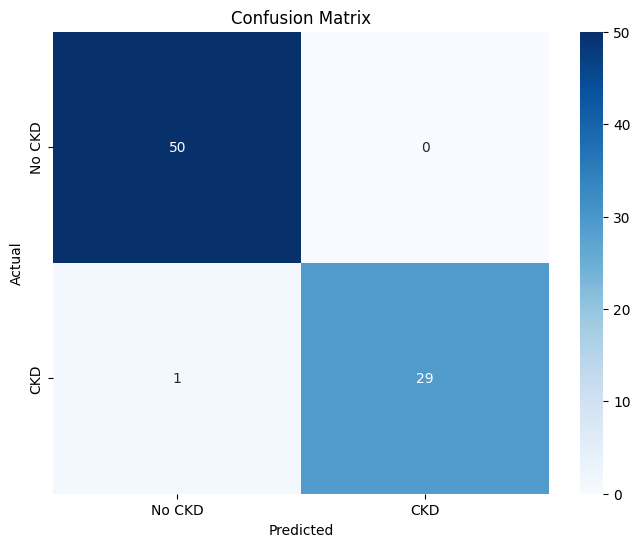

In [51]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No CKD', 'CKD'], 
            yticklabels=['No CKD', 'CKD'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

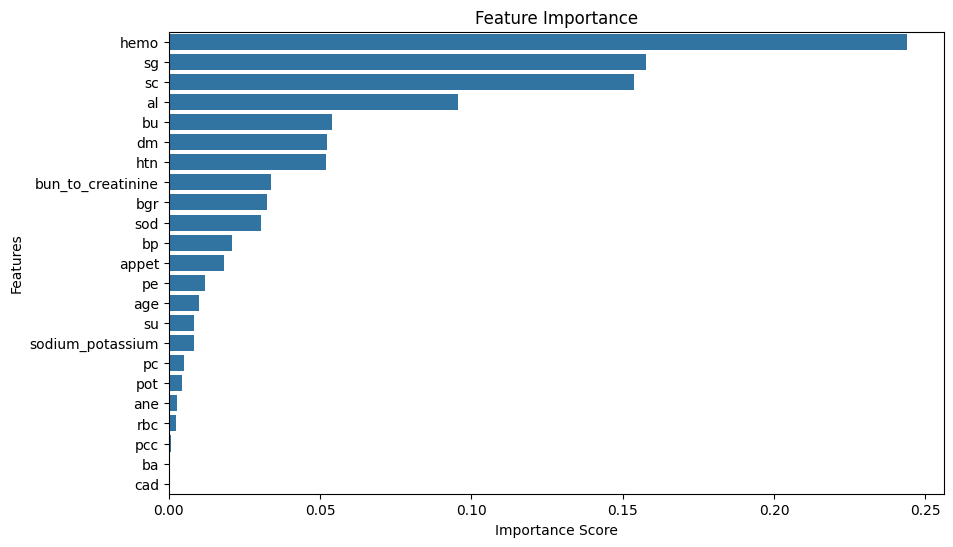

In [52]:
# Feature Importance
if hasattr(best_model.named_steps['model'], 'feature_importances_'):
    importances = best_model.named_steps['model'].feature_importances_
    feature_names = X.columns
    feature_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature_imp.values, y=feature_imp.index)
    plt.title('Feature Importance')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.show()